In [4]:
from dotenv import load_dotenv

_ = load_dotenv()

In [19]:
!pip install langchain_community
!pip install langchain_openai
!pip install langchain_core
!pip install langchain-groq #freemodel
!pip install langgraph.checkpoint.sqlite

In [8]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
import os
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from google.colab import userdata


In [10]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

# memory = SqliteSaver.from_conn_string(':memory:')
memory = SqliteSaver(sqlite3.connect(':memory:', check_same_thread=False))

In [11]:
model = ChatGroq(temperature=0, model_name="llama-3.1-8b-instant")

In [9]:
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

### Defining system prompt for each node/agent

In [12]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [13]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""

In [14]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed:

------

{content}""" # we will pass the results from tavily search which the researchPlan and researchCritique Agent will give

In [15]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [16]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""

### Defining agent state

In [17]:
class AgentState(TypedDict):
    task: str #original task given by user
    plan: str #plan generated by planning agent
    draft: str # actual essay that is written by the writer agent
    critique: str
    content: List[str] #list of answers that will be generated after searching using tavily search tool
    revision_number: int
    max_revisions: int

In [21]:
#This is required because we want the model to return the query for search tool as a List[str]
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [23]:
!pip install tavily
from tavily import TavilyClient

tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

  Preparing metadata (setup.py) ... done
  Created wheel for tavily: filename=tavily-1.1.0-py3-none-any.whl size=6128 sha256=51147fc2d0ddf19c79511c045b94310618a8ec79f34e90b6f595e5f561fedbe0
  Stored in directory: /root/.cache/pip/wheels/a7/67/b7/9aec4851724de28ac2bc34ff10b042af43d7f2dd1552e5906e
Successfully built tavily


### Defining Different Nodes


In [24]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [25]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [26]:
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content) # we are passing all the results from search client
        ),
        user_message # we are also passing actual human task and the plan
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content,
        "revision_number": state.get("revision_number", 1) + 1
    }


In [27]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [28]:
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [29]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

### Buidling a lang graph together

In [30]:
builder = StateGraph(AgentState)

In [31]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [32]:
builder.set_entry_point("planner")

In [33]:
builder.add_conditional_edges(
    "generate",
    should_continue,
    {END: END, "reflect": "reflect"}
)


In [34]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [35]:
graph = builder.compile(checkpointer=memory)

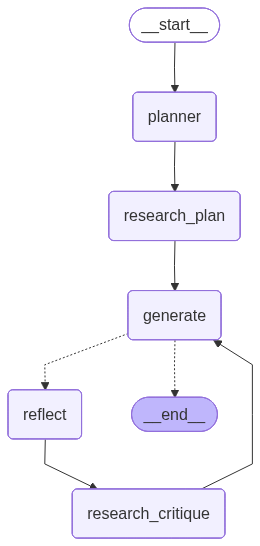

In [52]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### call the graph with parameters

In [49]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
    "content": [] # Initialize content as an empty list
}, thread):
    print(s)

{'planner': {'plan': "Here's a high-level outline for an essay on the differences between LangChain and LangSmith:\n\n**I. Introduction**\n- Briefly introduce the topic of AI research and development\n- Mention the emergence of new AI tools and platforms\n- Thesis statement: LangChain and LangSmith are two distinct AI platforms that have gained popularity in recent times, but they differ significantly in their approach, functionality, and use cases.\n\n**II. Overview of LangChain**\n- Define LangChain and its core features\n- Explain LangChain's focus on building conversational AI models\n- Discuss LangChain's architecture and how it enables developers to create custom conversational interfaces\n- Note: LangChain is an open-source platform that allows developers to build, train, and deploy conversational AI models.\n\n**III. Overview of LangSmith**\n- Define LangSmith and its core features\n- Explain LangSmith's focus on natural language processing (NLP) and text generation\n- Discuss 